# Analyse exploratoire

In [945]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

import re
import nltk

from nltk.stem import WordNetLemmatizer

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
nltk.download('stopwords') # python -m spacy download en_core_web_sm
stop_words = set(stopwords.words('english'))
negations = {"not", "no", "never", "neither"} # On exclue ces stopwords car elle influent sur le sens de la phrase
custom_stop_words = stop_words - negations

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import joblib

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import TextVectorization, Dense, Dropout, Embedding, GlobalAveragePooling1D, Bidirectional, LSTM
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administrateur\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Distribution des classes : le corpus est-il équilibré ?

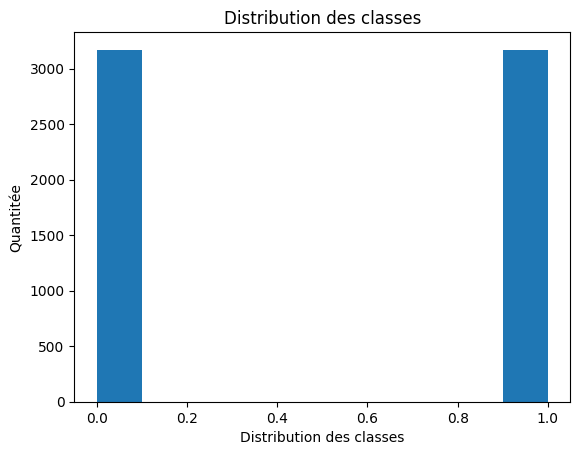

In [946]:
df = pd.read_csv("../data/titles_clean.csv")

plt.figure()
plt.hist(df["label"], bins=10)
plt.xlabel("Distribution des classes")
plt.ylabel("Quantitée")
plt.title("Distribution des classes")
plt.savefig("../figures/distribution_classes", dpi=300, bbox_inches='tight')
plt.show()
plt.close()

Distribution de la longueur des titres en tokens

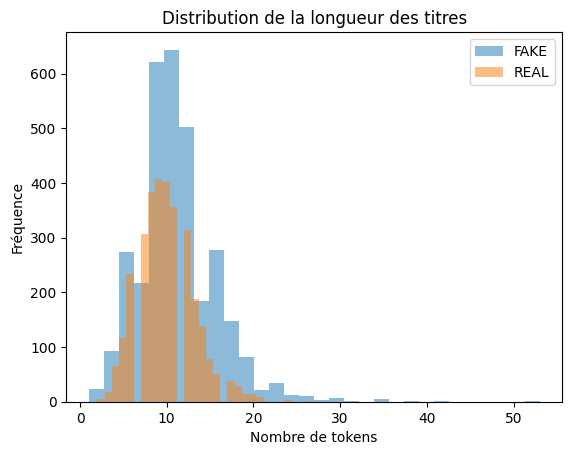

In [947]:
df["length"] = df["text"].apply(lambda x: len(str(x).split()))

fake = df[df["label"] == 0]["length"]
real = df[df["label"] == 1]["length"]

plt.figure()
plt.hist(fake, bins=30, alpha=0.5, label="FAKE")
plt.hist(real, bins=30, alpha=0.5, label="REAL")

plt.xlabel("Nombre de tokens")
plt.ylabel("Fréquence")
plt.title("Distribution de la longueur des titres")
plt.legend()

plt.show()

Top 20 des tokens les plus fréquents dans chaque classe — affichez deux diagrammes en barres côte à côte

Approche : 

    - Récupérer la liste des tokens (mots) dans chaque titre

    - Faire la somme des tokens pour chaque classe

    - Récupérer le top 20 des tokens les plus fréquents dans les 2 classes
    
    - Créer le diagramme en barre

0                      [you, can, smell, hillary’s, fear]
1       [watch, the, exact, moment, paul, ryan, commit...
2       [kerry, to, go, to, paris, in, gesture, of, sy...
3       [bernie, supporters, on, twitter, erupt, in, a...
4       [the, battle, of, new, york:, why, this, prima...
                              ...                        
6330    [state, department, says, it, can't, find, ema...
6331    [the, ‘p’, in, pbs, should, stand, for, ‘pluto...
6332    [anti-trump, protesters, are, tools, of, the, ...
6333    [in, ethiopia,, obama, seeks, progress, on, pe...
6334    [jeb, bush, is, suddenly, attacking, trump., h...
Name: tokens, Length: 6335, dtype: object


Top 20 des mots les plus fréquents dans les fakes news : [('the', 1137), ('to', 898), ('of', 642), ('in', 556), ('for', 413), ('on', 404), ('and', 372), ('trump', 360), ('a', 353), ('is', 346), ('hillary', 326), ('clinton', 265), ('by', 218), ('with', 181), ('–', 171), ('-', 161), ('from', 149), ('election', 141), ('new', 137), ('us', 136)]
Top 20 des mots les plus fréquents dans les news : [('the', 954), ('to', 812), ('in', 589), ('of', 447), ('trump', 433), ('for', 381), ('a', 371), ('on', 348), ('is', 341), ('and', 315), ('clinton', 285), ('gop', 213), ('obama', 193), ('donald', 185), ('hillary', 168), ('why', 162), ('how', 145), ('as', 138), ('new', 136), ('with', 135)]
(1137, 898, 642, 556, 413, 404, 372, 360, 353, 346, 326, 265, 218, 181, 171, 161, 149, 141, 137, 136)
(954, 812, 589, 447, 433, 381, 371, 348, 341, 315, 285, 213, 193, 185, 168, 162, 145, 138, 136, 135)


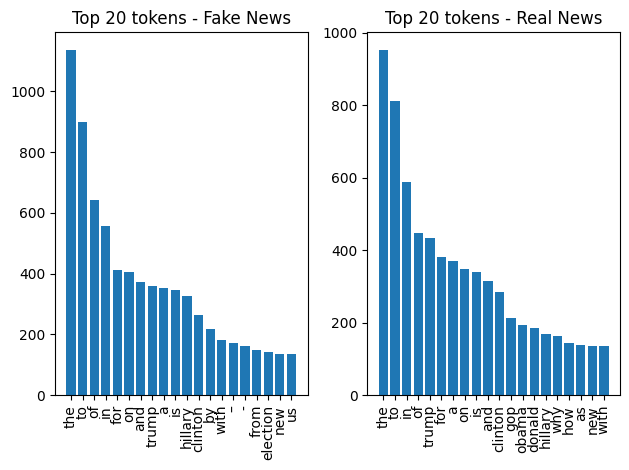

In [948]:
df["tokens"] = df["text"].apply(lambda x: str(x).lower().split()) 

print(df["tokens"])

fake_news_tokens_sum = df[df["label"] == 0]["tokens"].sum()
real_new_tokens_sum = df[df["label"] == 1]["tokens"].sum()

fake_news_counts = Counter(fake_news_tokens_sum).most_common(20)
real_news_counts = Counter(real_new_tokens_sum).most_common(20)

print(f"Top 20 des mots les plus fréquents dans les fakes news : {fake_news_counts}")
print(f"Top 20 des mots les plus fréquents dans les news : {real_news_counts}")

fake_news_token, fake_news_counter = zip(*fake_news_counts)
real_new_token, real_news_counter = zip(*real_news_counts)

print(fake_news_counter)
print(real_news_counter)

fig, axes = plt.subplots(1, 2)

axes[0].bar(fake_news_token, fake_news_counter)
axes[0].set_title("Top 20 tokens - Fake News")
axes[0].tick_params(axis='x', rotation=90)

axes[1].bar(real_new_token, real_news_counter)
axes[1].set_title("Top 20 tokens - Real News")
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

Identification des tokens présents dans une seule classe (discriminants purs) : listez les 10 premiers par classe

Identifiez au moins 3 titres potentiellement ambigus (ni clairement fiables, ni clairement trompeurs) et expliquez pourquoi ils posent problème

# Nettoyage et prétraitement

### Nettoyage

In [949]:
contractions_dict = {
        "don't": "do not",
        "doesn't": "does not",
        "didn't": "did not",
        "can't": "cannot",
        "couldn't": "could not",
        "won't": "will not",
        "wouldn't": "would not",
        "isn't": "is not",
        "aren't": "are not",
        "wasn't": "was not",
        "weren't": "were not",
        "haven't": "have not",
        "hasn't": "has not",
        "hadn't": "had not",
        "i'm": "i am",
        "you're": "you are",
        "they're": "they are",
        "it's": "it is",
        "there's": "there is",
        "we're": "we are",
        "she's": "she is",
        "he's": "he is"
    }

In [950]:
def clean_title(text:str) -> str:
    text = text.lower() # Mise en minuscules
    text = re.sub(r'@\w+', '', text) # Suppression des URLs et des mentions de type @username
    text = re.sub(r'[^\w\s]', '', text)  # Suppression de la ponctuation
    text = re.sub(r'\b\d+\b', '', text)  # Suppression des nombres isolés
    
    contraction_pattern = re.compile(r'\b(' + '|'.join(re.escape(k) for k in contractions_dict.keys()) + r')\b') # Remplace les contractions
    text = contraction_pattern.sub(lambda x: contractions_dict[x.group()], text)

    tokens = word_tokenize(text)
    tokens = [token for token in tokens if token.lower() not in custom_stop_words]
    tokens = [WordNetLemmatizer().lemmatize(token) for token in tokens]
    
    return tokens

In [951]:
df["text_clean"] = df["text"].apply(clean_title)
print(df["text_clean"])

0                                  [smell, hillary, fear]
1       [watch, exact, moment, paul, ryan, committed, ...
2                   [kerry, go, paris, gesture, sympathy]
3       [bernie, supporter, twitter, erupt, anger, dnc...
4                    [battle, new, york, primary, matter]
                              ...                        
6330    [state, department, say, cant, find, email, cl...
6331                [p, pb, stand, plutocratic, pentagon]
6332    [antitrump, protester, tool, oligarchy, inform...
6333    [ethiopia, obama, seek, progress, peace, secur...
6334    [jeb, bush, suddenly, attacking, trump, here, ...
Name: text_clean, Length: 6335, dtype: object


### Mesure de l'impact du nettoyage

Taille du vocabulaire avant et après nettoyage

In [952]:
# Je créer un nouveau Dataframe, 2 colonnes :
    # --> taille de la list de tokens avant nettoyage
    # --> taille de la list de tokens après nettoyage
# Puis je calcule en pourcentage la différence entre les 2 columns

df_comparaison = pd.DataFrame()
df_comparaison["length_before_cleaning"] = df["text"].apply(lambda x: len(str(x).split()))
df_comparaison["length_after_cleaning"] = df["text_clean"].apply(len)

total_before = df_comparaison["length_before_cleaning"].sum()
total_after = df_comparaison["length_after_cleaning"].sum()

reduction_total_pct = (total_before - total_after) / total_before * 100

print(f"Réduction totale des tokens après nettoyage : {reduction_total_pct:.2f}%")

Réduction totale des tokens après nettoyage : 29.62%


Réduction moyenne de la longueur des titres (en tokens)

In [953]:
df_comparaison["diff_tokens"] = df_comparaison["length_before_cleaning"] - df_comparaison["length_after_cleaning"]
reduction_moyenne_tokens = df_comparaison["diff_tokens"].mean()

print(f"Réduction moyenne de la longueur des titres : {reduction_moyenne_tokens:.2f}")

Réduction moyenne de la longueur des titres : 3.11


Nombre de titres devenus vides après nettoyage

In [954]:
empty_titles = df[df["text_clean"].apply(lambda x: len(x) == 0)]
print(f"Nombre de titres vides après nettoyage : {len(empty_titles)}")

Nombre de titres vides après nettoyage : 1


In [955]:
df = df[df["text_clean"].apply(len) > 0].reset_index(drop=True) # Je fais le choix de supprimer les quelques rares titres vides

empty_titles = df[df["text_clean"].apply(lambda x: len(x) == 0)]
print(f"Nombre de titres vides après correction : {len(empty_titles)}")
print(len(df["text_clean"]))
print(len(df["label"]))

Nombre de titres vides après correction : 0
6334
6334


In [956]:
dataset_cleaned = []
for text in df["text_clean"]:
    dataset_cleaned.append(" ".join(text))

print(len(dataset_cleaned))

6334


# Représentation vectorielle

### Vectorisation TF-IDF

In [957]:
vectorizer = TfidfVectorizer(
    max_features=3000,
    min_df=2,
    max_df=0.85,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X = dataset_cleaned
y = df["label"]

Découpez le corpus en train (80 %) et test (20 %) avec stratification sur les labels et random_state=42

In [958]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Entraînez le vectoriseur uniquement sur le train, transformez train et test séparément

In [959]:
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [979]:
joblib.dump(vectorizer, "../models/tfidf_vectorizer.joblib")

['../models/tfidf_vectorizer.joblib']

### Embedding avec TensorFlow

In [961]:
embedding_vectorizer = TextVectorization(
    max_tokens=5000,
    output_sequence_length=30
)

embedding_vectorizer.adapt(X_train)

X_train_seq = embedding_vectorizer(X_train)
X_test_seq = embedding_vectorizer(X_test)

# Modélisation

### Modèle baseline — réseau dense sur TF-IDF

In [962]:
X_train_dense = X_train_tfidf.toarray()
X_test_dense = X_test_tfidf.toarray()

In [963]:
tfidf_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_dense.shape[1],)),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

tfidf_model.summary()

c:\Users\Administrateur\Desktop\Github\fake-news-detection-nlp\.venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_44"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_118 (Dense)               │ (None, 256)            │       768,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_74 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_119 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_75 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_120 (Dense)               │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 801,281 (3.06 MB)

 Trainable params: 801,281 (3.06 MB)

 Non-trainable params: 0 (0.00 B)

Compilez avec optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']

In [964]:
tfidf_model.compile(
    optimizer="adam",
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Utilisez les callbacks suivants :

- EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss')

- ModelCheckpoint pour sauvegarder le meilleur modèle

In [965]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "../models/best_tfidf_model.keras",
    monitor='val_loss',
    save_best_only=True
)

Entraînez sur 30 epochs avec validation_split=0.15

In [966]:
history = tfidf_model.fit(
    X_train_dense,
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.15,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

Epoch 1/30


135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7018 - loss: 0.5871 - val_accuracy: 0.8134 - val_loss: 0.4380
Epoch 2/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8725 - loss: 0.3079 - val_accuracy: 0.8095 - val_loss: 0.4471
Epoch 3/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9296 - loss: 0.1793 - val_accuracy: 0.7963 - val_loss: 0.5536
Epoch 4/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9663 - loss: 0.0975 - val_accuracy: 0.7884 - val_loss: 0.6557
Epoch 5/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9847 - loss: 0.0496 - val_accuracy: 0.7898 - val_loss: 0.8046
Epoch 6/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9914 - loss: 0.0305 - val_accuracy: 0.7858 - val_loss: 0.9245
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 1.


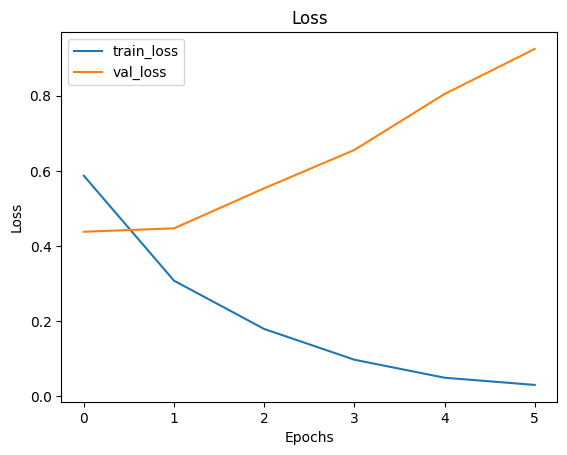

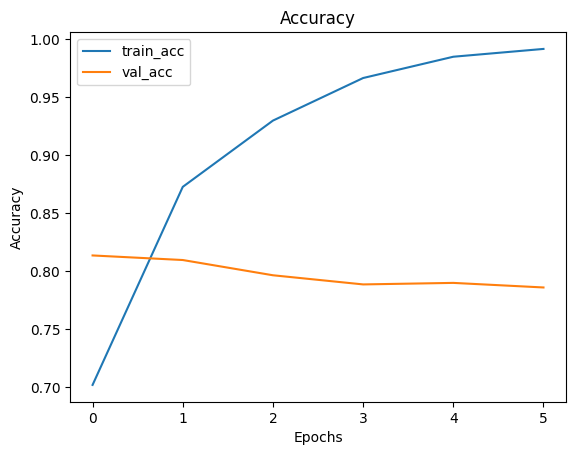

In [967]:
plt.figure()
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

plt.figure()
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

### Modèle avec embeddings appris — architecture séquentielle

In [968]:
embedding_model = Sequential([
    # embedding_vectorizer,
    Embedding(input_dim=5000, input_shape=(X_train_seq.shape[1],),output_dim=64, mask_zero=True),
    Bidirectional(LSTM(64, dropout=0.2, recurrent_dropout=0.2)),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

embedding_model.summary()

c:\Users\Administrateur\Desktop\Github\fake-news-detection-nlp\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_45"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ (None, 30, 64)         │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_14                │ (None, 128)            │        66,048 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_121 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_76 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_122 (Dense)               │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,369 (1.50 MB)

 Trainable params: 394,369 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

In [969]:
embedding_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [970]:
early_stopping = EarlyStopping(
    patience=5,
    restore_best_weights=True,
    monitor='val_loss'
)

checkpoint = ModelCheckpoint(
    "../models/best_embedding_model.keras",
    monitor='val_loss',
    save_best_only=True
)

In [971]:
history_emb = embedding_model.fit(
    X_train_seq,   
    y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.15,  
    callbacks=[early_stopping, checkpoint],
    verbose=1
)

Epoch 1/30


135/135 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.7065 - loss: 0.5492 - val_accuracy: 0.7858 - val_loss: 0.4579
Epoch 2/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.8932 - loss: 0.2733 - val_accuracy: 0.8371 - val_loss: 0.4404
Epoch 3/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.9457 - loss: 0.1511 - val_accuracy: 0.7898 - val_loss: 0.5585
Epoch 4/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9684 - loss: 0.0934 - val_accuracy: 0.7898 - val_loss: 0.7188
Epoch 5/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9772 - loss: 0.0653 - val_accuracy: 0.7884 - val_loss: 0.8140
Epoch 6/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9844 - loss: 0.0474 - val_accuracy: 0.7819 - val_loss: 1.0865
Epoch 7/30
135/135 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.9865 - loss: 0.0362 - val_accuracy: 0.7740 - val_loss: 1.1850


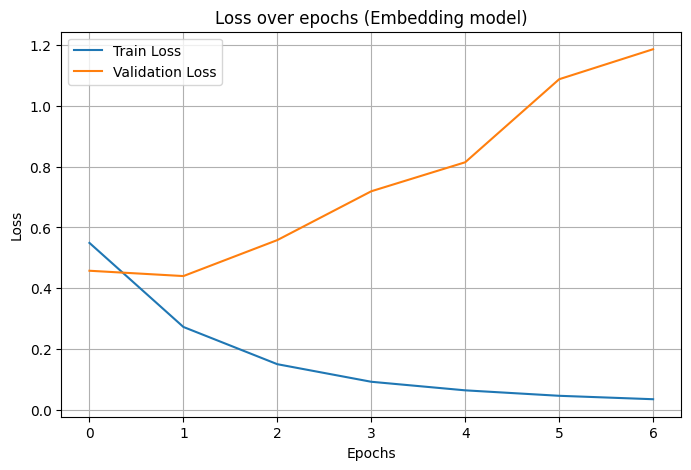

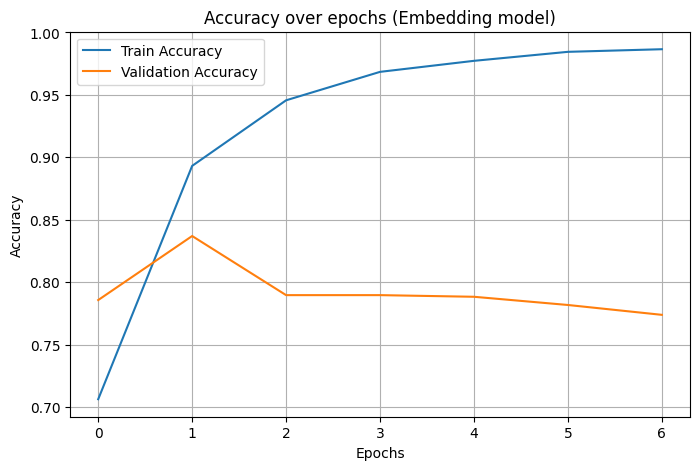

In [972]:
plt.figure(figsize=(8,5))
plt.plot(history_emb.history['loss'], label='Train Loss')
plt.plot(history_emb.history['val_loss'], label='Validation Loss')
plt.title("Loss over epochs (Embedding model)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(history_emb.history['accuracy'], label='Train Accuracy')
plt.plot(history_emb.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy over epochs (Embedding model)")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

 Comparaison des deux architectures

In [973]:
y_pred_dense = (tfidf_model.predict(X_test_tfidf) > 0.5).astype(int)
print("=== Dense (TF-IDF) ===")
print(classification_report(y_test, y_pred_dense, target_names=["REAL", "FAKE"]))
print("AUC-ROC:", roc_auc_score(y_test, tfidf_model.predict(X_test_tfidf)))
print("Params:", tfidf_model.count_params())
print(confusion_matrix(y_test, y_pred_dense))


y_pred_lstm = (embedding_model.predict(X_test_seq) > 0.5).astype(int)
print("\n=== LSTM  ===")
print(classification_report(y_test, y_pred_lstm, target_names=["REAL", "FAKE"]))
print("AUC-ROC:", roc_auc_score(y_test, embedding_model.predict(X_test_seq)))
print("Params:", embedding_model.count_params())
print(confusion_matrix(y_test, y_pred_lstm))

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
=== Dense (TF-IDF) ===
              precision    recall  f1-score   support

        REAL       0.79      0.78      0.78       633
        FAKE       0.78      0.79      0.79       634

    accuracy                           0.79      1267
   macro avg       0.79      0.79      0.79      1267
weighted avg       0.79      0.79      0.79      1267

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
AUC-ROC: 0.8699149311525409
Params: 801281
[[495 138]
 [134 500]]


40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step

=== LSTM  ===
              precision    recall  f1-score   support

        REAL       0.80      0.80      0.80       633
        FAKE       0.80      0.80      0.80       634

    accuracy                           0.80      1267
   macro avg       0.80      0.80      0.80      1267
weighted avg       0.80      0.80      0.80      1267

40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
AUC-ROC: 0.8905479888966964
Params: 394369
[[508 125]
 [127 507]]


### Évaluation approfondie (modele retenu --> LSTM)

Le rapport de classification

In [974]:
print(classification_report(y_test, y_pred_lstm, target_names=["REAL", "FAKE"]))

              precision    recall  f1-score   support

        REAL       0.80      0.80      0.80       633
        FAKE       0.80      0.80      0.80       634

    accuracy                           0.80      1267
   macro avg       0.80      0.80      0.80      1267
weighted avg       0.80      0.80      0.80      1267



La matrice de confusion annotée

In [975]:
print(confusion_matrix(y_test, y_pred_lstm))

[[508 125]
 [127 507]]


### Analyse des erreurs

### Robustesse

In [976]:
data_test = [
    "Scientists discover new treatment for common disease",
    "SHOCKING: Government hiding truth about water supply",
    "Local elections results announced in three counties",
    "You won't believe what this celebrity did last night",
    "Central bank raises interest rates by 0.25 points",
    "This one weird trick cures all allergies naturally",
    "Parliament votes on new environmental legislation",
    "Doctors don't want you to know this secret remedy",
    "Tech company reports quarterly earnings below forecast",
    "EXCLUSIVE: Famous actor reveals hidden agenda of elites"
]

In [977]:
data_test_seq = embedding_vectorizer(np.array(data_test))
y_pred = embedding_model.predict(data_test_seq)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


In [978]:
# Affichage lisible
print(f"{'Texte':<55} {'Score':>6}  {'Label'}")
print("-" * 75)
for text, score in zip(data_test, y_pred.flatten()):
    label = "FAKE" if score > 0.5 else "REAL"
    print(f"{text:<55} {score:.3f}   {label}")

Texte                                                    Score  Label
---------------------------------------------------------------------------
Scientists discover new treatment for common disease    0.157   REAL
SHOCKING: Government hiding truth about water supply    0.020   REAL
Local elections results announced in three counties     0.080   REAL
You won't believe what this celebrity did last night    0.559   FAKE
Central bank raises interest rates by 0.25 points       0.010   REAL
This one weird trick cures all allergies naturally      0.012   REAL
Parliament votes on new environmental legislation       0.255   REAL
Doctors don't want you to know this secret remedy       0.263   REAL
Tech company reports quarterly earnings below forecast  0.047   REAL
EXCLUSIVE: Famous actor reveals hidden agenda of elites 0.032   REAL
